In [11]:
import pandas as pd
import torch
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from huggingface_hub import login
import logging
from transformers import (
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification,
    # tokenizers
    AutoTokenizer,
    DebertaV2Tokenizer,
    DistilBertTokenizer,
    BertTokenizer,
    RobertaTokenizer,
    ElectraTokenizer,
    AlbertTokenizer,
    XLNetTokenizer,
    MobileBertTokenizer,
    # models
    DebertaV2ForSequenceClassification,
    DistilBertForSequenceClassification,
    BertForSequenceClassification,
    RobertaForSequenceClassification,
    ElectraForSequenceClassification,
    AlbertForSequenceClassification,
    XLNetForSequenceClassification,
    MobileBertForSequenceClassification,
)
from torch.nn import CrossEntropyLoss
# evaluation metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from collections import Counter

import transformers
print(transformers.__version__)
print(transformers.TrainingArguments)

# Cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

4.57.3
<class 'transformers.training_args.TrainingArguments'>


In [12]:
import pandas as pd
import numpy as np
import os
import json

from sklearn.metrics import accuracy_score, f1_score
from transformers import Trainer
from statsmodels.stats.contingency_tables import mcnemar  # pip install statsmodels if needed

# --- Load performance CSV (same as relavance_classifier_multi_nvidia.ipynb) ---
if os.path.exists("model_performance.csv"):
    perf_df = pd.read_csv("model_performance.csv")
elif os.path.exists("model_performance_nvidia.csv"):
    perf_df = pd.read_csv("model_performance_nvidia.csv")
else:
    raise FileNotFoundError(
        "Expected model_performance.csv or model_performance_nvidia.csv in the working directory."
    )

# Make sure model name is string
perf_df["model"] = perf_df["model"].astype(str)

# For each model, pick the row with the BEST F1
best_rows = (
    perf_df.sort_values(["model", "f1"], ascending=[True, False])
           .groupby("model", as_index=False)
           .first()
)

print("Best configuration per model (by F1):")
display(best_rows)

# List of (model_name, max_length) to use for statistical comparison
MODEL_RUNS = [(row["model"], int(row["max_length"])) for _, row in best_rows.iterrows()]
print("\nModel runs to evaluate:", MODEL_RUNS)

# Build (model_name, max_length) -> best_checkpoint path for loading exact checkpoints in statistical tests
best_checkpoint_map = {}
if "best_checkpoint" in perf_df.columns:
    for _, row in perf_df.iterrows():
        ckpt = row.get("best_checkpoint")
        if pd.notna(ckpt) and ckpt and str(ckpt).strip():
            best_checkpoint_map[(str(row["model"]), int(row["max_length"]))] = str(ckpt).strip()
else:
    for alt_name in ("model_performance.csv", "model_performance_nvidia.csv"):
        if not os.path.exists(alt_name):
            continue
        try:
            alt = pd.read_csv(alt_name)
            if "best_checkpoint" not in alt.columns:
                continue
            alt["model"] = alt["model"].astype(str)
            for _, row in alt.iterrows():
                ckpt = row.get("best_checkpoint")
                if pd.notna(ckpt) and ckpt and str(ckpt).strip():
                    best_checkpoint_map[(str(row["model"]), int(row["max_length"]))] = str(ckpt).strip()
            break
        except Exception:
            pass
print(f"Checkpoint map has {len(best_checkpoint_map)} (model, max_length) entries from CSV.")


Best configuration per model (by F1):


,model,max_length,train_time_sec,pred_time_sec,best_checkpoint,accuracy,f1,precision,recall
0,albert-base-v2,512,332.680437,9.699316,D:/huggingface_cache/classification_models/alb...,0.950158,0.949552,0.949776,0.950158
1,bert,128,115.494352,2.065423,D:/huggingface_cache/classification_models/ber...,0.954114,0.953927,0.953839,0.954114
2,bert-large-uncased,512,1194.447500,24.089855,D:/huggingface_cache/classification_models/ber...,0.958861,0.958982,0.959157,0.958861
3,deberta-large,256,1091.308000,18.075430,D:/huggingface_cache/classification_models/deb...,0.946203,0.945012,0.946408,0.946203
4,deberta-v3-base,256,306.035406,5.556699,D:/huggingface_cache/classification_models/deb...,0.951741,0.951764,0.951790,0.951741
5,deberta-v3-small,512,340.046688,8.684825,D:/huggingface_cache/classification_models/deb...,0.952532,0.951928,0.952234,0.952532
6,distilbert,128,55.118418,1.256317,D:/huggingface_cache/classification_models/dis...,0.952532,0.951874,0.952288,0.952532
7,electra-large,512,1399.067375,30.064797,D:/huggingface_cache/classification_models/ele...,0.955696,0.954823,0.956064,0.955696
8,electra-small,512,96.414687,2.563694,D:/huggingface_cache/classification_models/ele...,0.952532,0.951981,0.952192,0.952532
9,mobilebert,512,225.294656,5.039681,D:/huggingface_cache/classification_models/mob...,0.950949,0.950900,0.950857,0.950949



Model runs to evaluate: [('albert-base-v2', 512), ('bert', 128), ('bert-large-uncased', 512), ('deberta-large', 256), ('deberta-v3-base', 256), ('deberta-v3-small', 512), ('distilbert', 128), ('electra-large', 512), ('electra-small', 512), ('mobilebert', 512), ('roberta', 512), ('roberta-large', 256), ('xlm-roberta-base', 512), ('xlm-roberta-large', 256), ('xlnet', 512)]
Checkpoint map has 45 (model, max_length) entries from CSV.


In [13]:
# ---- Tuning parameters ----
# Kept in sync with relavance_classifier_multi_nvidia.ipynb (only output_dir is used here for checkpoint fallback).
# Size tiers and LRs follow convention from: Devlin et al. 2019 (BERT), Mosbach et al. 2021 (fine-tuning stability).
# Small <100M, Base/Medium ~110M, Large 300M+. Larger models use slightly lower LR for stable convergence.
CONFIG = {
    # epochs tuned by model size/type
    "epochs": 3,
    # batch sizes tuned by model size/type
    "batch_size": {
        "small": 16,
        "medium": 8,
        "large": 4
    },
    "max_length": [128, 256, 512],  # Max length of input sequences
    # learning rates by size (small -> higher, large -> lower; Devlin et al. 2e-5--5e-5)
    "learning_rate": {
        "small": 5e-5,
        "medium": 3e-5,
        "large": 2e-5
    },
    "weight_decay": 0.01,  # Weight decay for regularization
    "output_dir": "D:/huggingface_cache/classification_models"
}

# ---- Model configurations ----
# Ordered roughly by parameter count (small -> xxl). Each model has a 'type' key.
MODEL_CONFIGS = {
    # ---- XS (very small, <= ~20M) ----
    "albert-base-v2": {
        "type": "small",
        "tokenizer_class": AlbertTokenizer,
        "pretrained_model_name": "albert-base-v2",  # ~11M
        "model_class": AlbertForSequenceClassification
    },
    "electra-small": {
        "type": "small",
        "tokenizer_class": ElectraTokenizer,
        "pretrained_model_name": "google/electra-small-discriminator",  # ~14M
        "model_class": ElectraForSequenceClassification
    },
    # ---- S (small, ~20M-70M) ----
    "mobilebert": {
        "type": "small",
        "tokenizer_class": AutoTokenizer,
        "pretrained_model_name": "google/mobilebert-uncased",  # ~25M
        "model_class": MobileBertForSequenceClassification
    },
    "deberta-v3-small": {
        "type": "small",
        "tokenizer_class": DebertaV2Tokenizer,
        "pretrained_model_name": "microsoft/deberta-v3-small",  # ~55M
        "model_class": DebertaV2ForSequenceClassification
    },
    "distilbert": {
        "type": "small",
        "tokenizer_class": DistilBertTokenizer,
        "pretrained_model_name": "distilbert-base-uncased",  # ~66M
        "model_class": DistilBertForSequenceClassification
    },

    # ---- M (medium, ~70M-200M) ----
    "bert": {
        "type": "medium",
        "tokenizer_class": BertTokenizer,
        "pretrained_model_name": "bert-base-uncased",  # ~110M
        "model_class": BertForSequenceClassification
    },
    "xlnet": {
        "type": "medium",
        "tokenizer_class": XLNetTokenizer,
        "pretrained_model_name": "xlnet-base-cased",  # ~110M
        "model_class": XLNetForSequenceClassification
    },
    "roberta": {
        "type": "medium",
        "tokenizer_class": RobertaTokenizer,
        "pretrained_model_name": "roberta-base",  # ~125M
        "model_class": RobertaForSequenceClassification
    },
    "deberta-v3-base": {
        "type": "medium",
        "tokenizer_class": AutoTokenizer,
        "pretrained_model_name": "microsoft/deberta-v3-base",  # ~140M
        "model_class": AutoModelForSequenceClassification
    },
    "xlm-roberta-base": {
        "type": "medium",
        "tokenizer_class": AutoTokenizer,
        "pretrained_model_name": "xlm-roberta-base",  # ~270M
        "model_class": AutoModelForSequenceClassification
    },
    "bert-large-uncased": {
        "type": "large",
        "tokenizer_class": BertTokenizer,
        "pretrained_model_name": "bert-large-uncased",  # ~340M
        "model_class": BertForSequenceClassification
    },
    "roberta-large": {
        "type": "large",
        "tokenizer_class": RobertaTokenizer,
        "pretrained_model_name": "roberta-large",  # ~355M
        "model_class": RobertaForSequenceClassification
    },
    "electra-large": {
        "type": "large",
        "tokenizer_class": ElectraTokenizer,
        "pretrained_model_name": "google/electra-large-discriminator",  # ~335M
        "model_class": ElectraForSequenceClassification
    },
    # ---- XL (extra large, ~400M-800M) ----
    "xlm-roberta-large": {
        "type": "large",
        "tokenizer_class": AutoTokenizer,
        "pretrained_model_name": "xlm-roberta-large",  # ~550M
        "model_class": AutoModelForSequenceClassification
    },
    # ---- XXL (very large, > ~800M) ----
    "deberta-large": {
        "type": "large",
        "tokenizer_class": AutoTokenizer,
        "pretrained_model_name": "microsoft/deberta-large",  # very large (~>800M depending on variant)
        "model_class": AutoModelForSequenceClassification
    }
}


In [14]:
import re


def get_best_checkpoint(model_name):
    """
    Fix: scans all checkpoint-* folders under the model directory
    and reads trainer_state.json to find the best checkpoint.
    """
    model_dir = f"{CONFIG['output_dir']}/{model_name}"

    # Find all folders named checkpoint-xxxx
    checkpoint_dirs = [
        os.path.join(model_dir, d)
        for d in os.listdir(model_dir)
        if os.path.isdir(os.path.join(model_dir, d)) and re.match(r"checkpoint-\d+", d)
    ]

    if len(checkpoint_dirs) == 0:
        raise FileNotFoundError(f"No checkpoint-* folders found for {model_name} in {model_dir}")

    best_ckpt = None
    best_metric = -9999

    for ckpt_dir in checkpoint_dirs:
        state_file = os.path.join(ckpt_dir, "trainer_state.json")
        if not os.path.exists(state_file):
            continue

        with open(state_file, "r") as f:
            state = json.load(f)

        # Try to get best_metric; fallback to "eval_f1" if present
        metric = state.get("best_metric", None)
        if metric is None:
            # look in logs
            logs = state.get("log_history", [])
            for log in logs:
                if "eval_f1" in log:
                    metric = log["eval_f1"]

        if metric is None:
            continue

        if metric > best_metric:
            best_metric = metric
            best_ckpt = ckpt_dir

    if best_ckpt is None:
        raise ValueError(f"No valid checkpoint with metrics found for {model_name}")

    print(f"[BEST CHECKPOINT] {model_name} → {best_ckpt} (best_metric={best_metric})")
    return best_ckpt


def get_checkpoint_for_run(model_name, max_len):
    """
    Return the checkpoint path for (model_name, max_length).
    Uses best_checkpoint_map from CSV when available; otherwise falls back to get_best_checkpoint(model_name).
    """
    key = (model_name, max_len)
    if key in best_checkpoint_map:
        path = best_checkpoint_map[key]
        path = os.path.normpath(path) if isinstance(path, str) else path
        print(f"[BEST CHECKPOINT] {model_name} (max_len={max_len}) → {path} (from CSV)")
        return path
    return get_best_checkpoint(model_name)

In [15]:
# Load the labeled chunks
with open("exported_chunks.jsonl", "r", encoding="utf-8") as f:
    labeled_chunks = [json.loads(line) for line in f]

data = pd.DataFrame(labeled_chunks)
labeled_count = data['label'].value_counts().to_dict()

# Get the first 9000 rows
data = data.head(9000)

# Remove rows with label == 11
data = data[data['label'] != 11]

# Print labeled count after removing label 11
labeled_count = data['label'].value_counts().to_dict()
print(f"Labeled chunks after removing label 11: {labeled_count}")

# Remove rows where label == 1 and text length < 100
data = data[~((data['label'] == 1) & (data['text'].str.len() < 100))]

# Keep only chunks with at least MIN_CHUNK_TOKENS (tokenizer-based)
MIN_CHUNK_TOKENS = 20
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
data = data[data["text"].apply(lambda t: len(tokenizer.encode(t, truncation=True, max_length=512)) >= MIN_CHUNK_TOKENS)]

# Print final labeled count
labeled_count = data['label'].value_counts().to_dict()
print(f"Final labeled chunks (after >= {MIN_CHUNK_TOKENS} token cutoff): {labeled_count}")


Labeled chunks after removing label 11: {1: 5465, 0: 3535}
Final labeled chunks (after >= 20 token cutoff): {1: 4681, 0: 1635}


In [16]:
# Loading the data
data['label'] = data['label'].astype(int)

# Train-Test Split using stratified sampling
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)

# since there is a class imbalance, we will compute class weights
# to handle this in the loss function
labels = train_df["label"].values
# Compute class weights
classes = np.unique(labels)
weights = compute_class_weight(class_weight="balanced",
                            classes=classes,
                            y=labels)
class_weights = torch.tensor(weights, dtype=torch.float, device=device)
print("Class weights:", class_weights)

# Convert ing the DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

Class weights: tensor([1.9312, 0.6747], device='cuda:0')


In [17]:
all_predictions = {}
y_true_global = None  # we'll store y_true once
import re
def regenerate_predictions(model_name, max_len):
    global y_true_global

    print(f"\n► Regenerating predictions for: {model_name} (max_len={max_len})")

    cfg = MODEL_CONFIGS[model_name]
    best_ckpt = get_checkpoint_for_run(model_name, max_len)

    # Load tokenizer & model from best checkpoint
    tokenizer = cfg["tokenizer_class"].from_pretrained(cfg["pretrained_model_name"])
    model = cfg["model_class"].from_pretrained(
        best_ckpt,
        num_labels=len(data['label'].unique())
    ).to(device)

    # Tokenize test set
    def tokenize_fn(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_len
        )

    test_enc = test_dataset.map(tokenize_fn, batched=True)
    test_enc = test_enc.rename_column("label", "labels")
    test_enc.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )

    # Use Trainer for prediction only
    trainer = Trainer(model=model, tokenizer=tokenizer)
    preds = trainer.predict(test_enc)

    y_true = preds.label_ids
    y_pred = preds.predictions.argmax(-1)
    y_prob = preds.predictions  # logits

    if y_true_global is None:
        y_true_global = y_true
        np.save("y_true.npy", y_true)
    else:
        # sanity check
        assert np.array_equal(y_true_global, y_true), "y_true changed across models!"

    key = f"{model_name}_len{max_len}"
    all_predictions[key] = {
        "model": model_name,
        "max_length": max_len,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    # Save to disk
    np.save(f"preds_{key}.npy", y_pred)
    np.save(f"probs_{key}.npy", y_prob)

    return key


# ---- Run for selected (model, max_length) combos ----
model_keys = []
for model_name, max_len in MODEL_RUNS:
    try:
        key = regenerate_predictions(model_name, max_len)
        model_keys.append(key)
    except Exception as e:
        print(f"⚠️ Skipping {model_name} (len={max_len}) due to error: {e}")

print("\nFinished regenerating predictions for keys:")
print(model_keys)



► Regenerating predictions for: albert-base-v2 (max_len=512)
[BEST CHECKPOINT] albert-base-v2 (max_len=512) → D:\huggingface_cache\classification_models\albert-base-v2\checkpoint-948 (from CSV)


Map:   0%|          | 0/1264 [00:00<?, ? examples/s]

C:\Users\ctngweru\AppData\Local\Temp\ipykernel_56640\2090964844.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)



► Regenerating predictions for: bert (max_len=128)
[BEST CHECKPOINT] bert (max_len=128) → D:\huggingface_cache\classification_models\bert\checkpoint-1264 (from CSV)


Map:   0%|          | 0/1264 [00:00<?, ? examples/s]

...


► Regenerating predictions for: xlm-roberta-large (max_len=256)
[BEST CHECKPOINT] xlm-roberta-large (max_len=256) → D:\huggingface_cache\classification_models\xlm-roberta-large\checkpoint-2526 (from CSV)


Map:   0%|          | 0/1264 [00:00<?, ? examples/s]


► Regenerating predictions for: xlnet (max_len=512)
[BEST CHECKPOINT] xlnet (max_len=512) → D:\huggingface_cache\classification_models\xlnet\checkpoint-1264 (from CSV)


Map:   0%|          | 0/1264 [00:00<?, ? examples/s]


Finished regenerating predictions for keys:
['albert-base-v2_len512', 'bert_len128', 'bert-large-uncased_len512', 'deberta-large_len256', 'deberta-v3-base_len256', 'deberta-v3-small_len512', 'distilbert_len128', 'electra-large_len512', 'electra-small_len512', 'mobilebert_len512', 'roberta_len512', 'roberta-large_len256', 'xlm-roberta-base_len512', 'xlm-roberta-large_len256', 'xlnet_len512']


In [18]:
from sklearn.metrics import precision_recall_fscore_support

def metric_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def metric_f1_weighted(y_true, y_pred):
    return f1_score(y_true, y_pred, average="weighted")

def bootstrap_ci_for_model(key, metric_fn, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = all_predictions[key]["y_true"]
    y_pred = all_predictions[key]["y_pred"]
    N = len(y_true)

    stats = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, N, N)
        stats[i] = metric_fn(y_true[idx], y_pred[idx])

    point_est = metric_fn(y_true, y_pred)
    low = np.percentile(stats, 2.5)
    high = np.percentile(stats, 97.5)
    return point_est, low, high

# ---- Build summary table with bootstrap CIs ----
bootstrap_rows = []
for key in model_keys:
    mname = all_predictions[key]["model"]
    mlen = all_predictions[key]["max_length"]

    acc, acc_low, acc_high = bootstrap_ci_for_model(key, metric_accuracy)
    f1, f1_low, f1_high = bootstrap_ci_for_model(key, metric_f1_weighted)

    bootstrap_rows.append({
        "key": key,
        "model": mname,
        "max_length": mlen,
        "accuracy": acc,
        "accuracy_ci_low": acc_low,
        "accuracy_ci_high": acc_high,
        "f1_weighted": f1,
        "f1_ci_low": f1_low,
        "f1_ci_high": f1_high,
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)
print("\nBootstrap CI summary:")
display(bootstrap_df)

bootstrap_df.to_csv("model_bootstrap_ci_results.csv", index=False)



Bootstrap CI summary:


,key,model,max_length,accuracy,accuracy_ci_low,accuracy_ci_high,f1_weighted,f1_ci_low,f1_ci_high
0,albert-base-v2_len512,albert-base-v2,512,0.950158,0.937500,0.961234,0.949552,0.936562,0.960946
1,bert_len128,bert,128,0.948576,0.935918,0.959652,0.947470,0.934533,0.959022
2,bert-large-uncased_len512,bert-large-uncased,512,0.958861,0.947785,0.969146,0.958982,0.948058,0.969040
3,deberta-large_len256,deberta-large,256,0.935918,0.922468,0.949367,0.936882,0.923611,0.949746
4,deberta-v3-base_len256,deberta-v3-base,256,0.950158,0.938271,0.961234,0.950695,0.938728,0.961701
5,deberta-v3-small_len512,deberta-v3-small,512,0.952532,0.939873,0.963608,0.951928,0.939368,0.963063
6,distilbert_len128,distilbert,128,0.949367,0.937500,0.960443,0.948309,0.935746,0.959989
7,electra-large_len512,electra-large,512,0.955696,0.943829,0.965981,0.954823,0.942666,0.965525
8,electra-small_len512,electra-small,512,0.952532,0.940665,0.963608,0.951981,0.939538,0.963117
9,mobilebert_len512,mobilebert,512,0.950949,0.939063,0.962025,0.950900,0.938551,0.962101


In [19]:
import itertools

def mcnemar_two(key_a, key_b):
    y_true = all_predictions[key_a]["y_true"]
    A = all_predictions[key_a]["y_pred"]
    B = all_predictions[key_b]["y_pred"]

    # b = A wrong, B correct
    # c = A correct, B wrong
    b_err = np.sum((A != y_true) & (B == y_true))
    c_err = np.sum((A == y_true) & (B != y_true))

    table = [[0, b_err],
             [c_err, 0]]

    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue, b_err, c_err

pair_results = []
for key_a, key_b in itertools.combinations(model_keys, 2):
    stat, pval, b_err, c_err = mcnemar_two(key_a, key_b)

    pair_results.append({
        "model_a": all_predictions[key_a]["model"],
        "max_len_a": all_predictions[key_a]["max_length"],
        "key_a": key_a,
        "model_b": all_predictions[key_b]["model"],
        "max_len_b": all_predictions[key_b]["max_length"],
        "key_b": key_b,
        "mcnemar_chi2": stat,
        "p_value": pval,
        "b_err_A_wrong_B_right": b_err,
        "c_err_A_right_B_wrong": c_err,
    })

mcnemar_df = pd.DataFrame(pair_results)
print("\nPairwise McNemar test results:")
display(mcnemar_df.head())

mcnemar_df.to_csv("mcnemar_pairwise_results.csv", index=False)



Pairwise McNemar test results:


,model_a,max_len_a,key_a,model_b,max_len_b,key_b,mcnemar_chi2,p_value,b_err_A_wrong_B_right,c_err_A_right_B_wrong
0,albert-base-v2,512,albert-base-v2_len512,bert,128,bert_len128,0.022727,0.880168,21,23
1,albert-base-v2,512,albert-base-v2_len512,bert-large-uncased,512,bert-large-uncased_len512,1.960784,0.161429,31,20
2,albert-base-v2,512,albert-base-v2_len512,deberta-large,256,deberta-large_len256,3.802632,0.051172,29,47
3,albert-base-v2,512,albert-base-v2_len512,deberta-v3-base,256,deberta-v3-base_len256,0.016129,0.898940,31,31
4,albert-base-v2,512,albert-base-v2_len512,deberta-v3-small,512,deberta-v3-small_len512,0.097561,0.754776,22,19


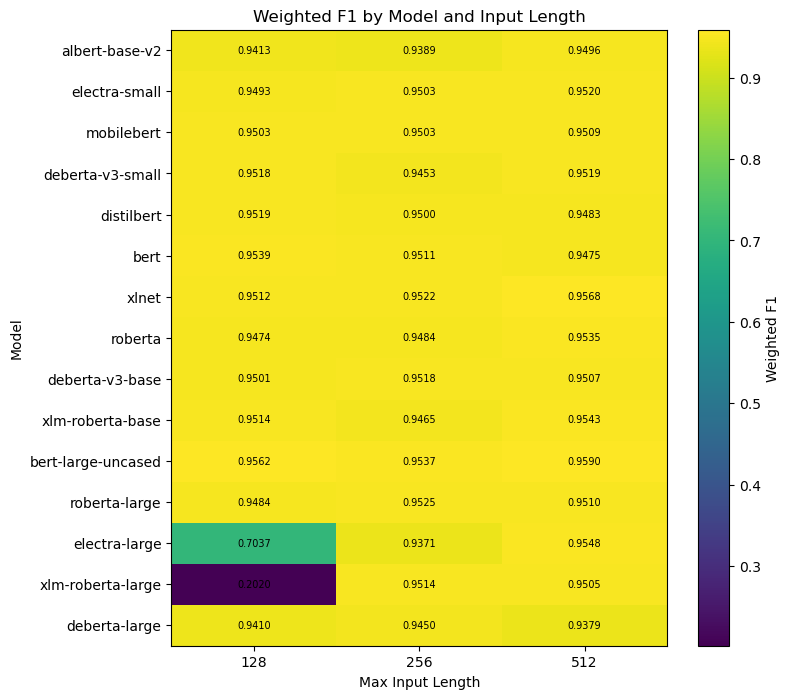

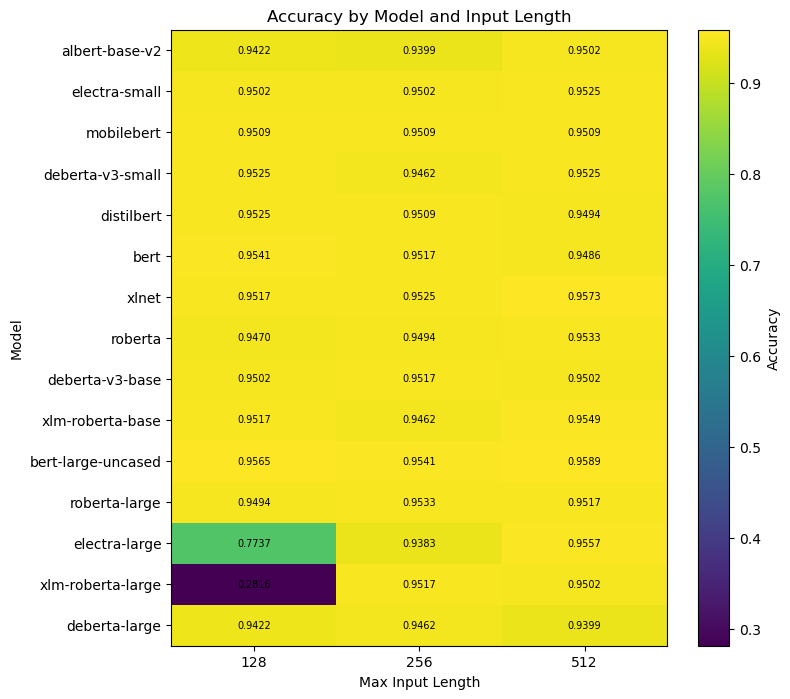

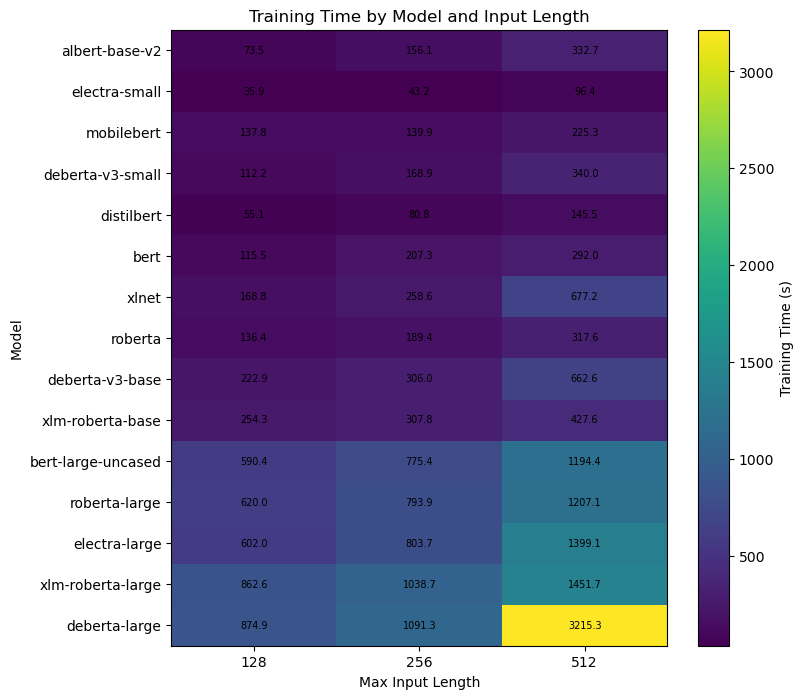

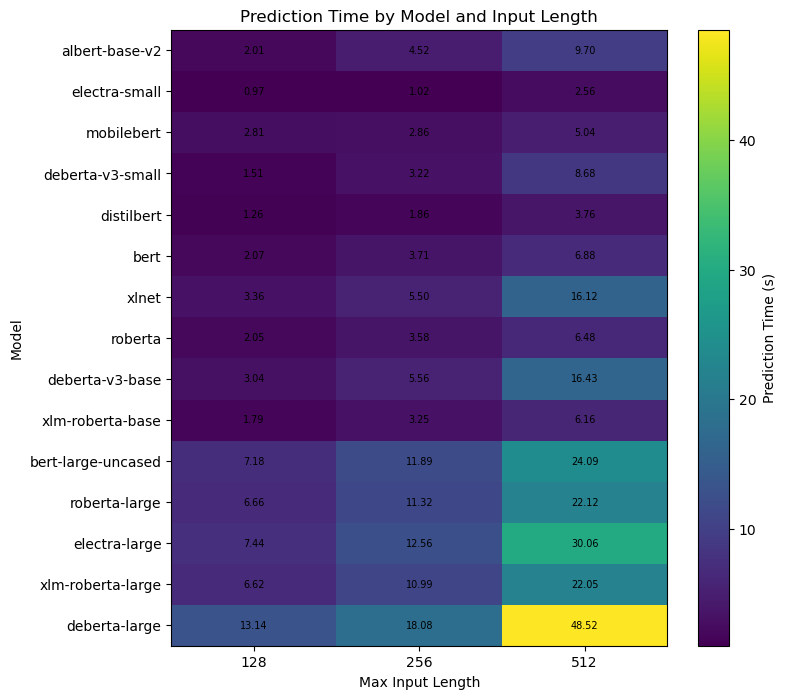

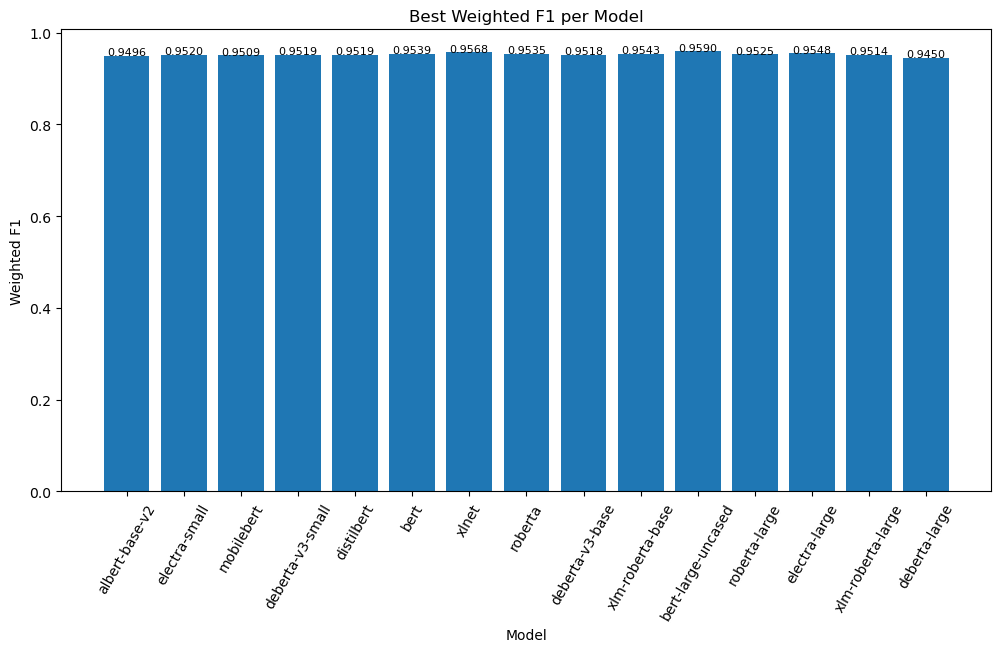

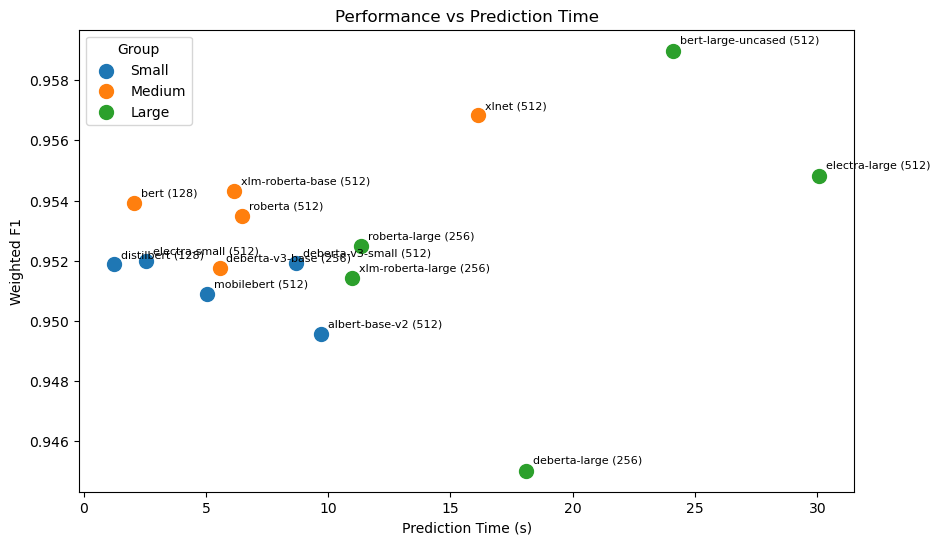

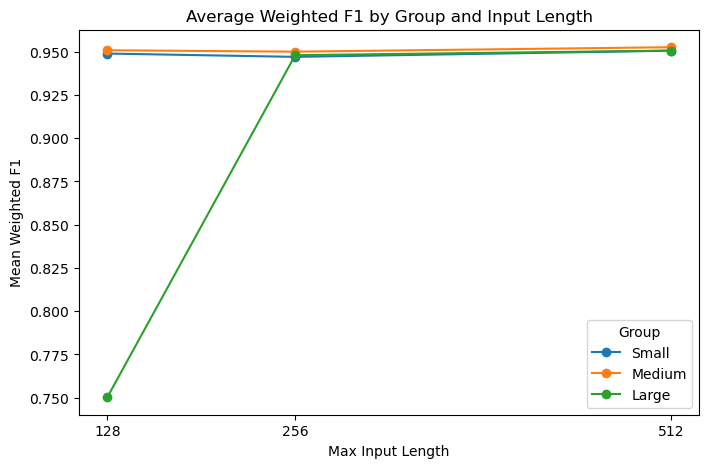

Bootstrap columns: ['key', 'model', 'max_length', 'accuracy', 'accuracy_ci_low', 'accuracy_ci_high', 'f1_weighted', 'f1_ci_low', 'f1_ci_high']


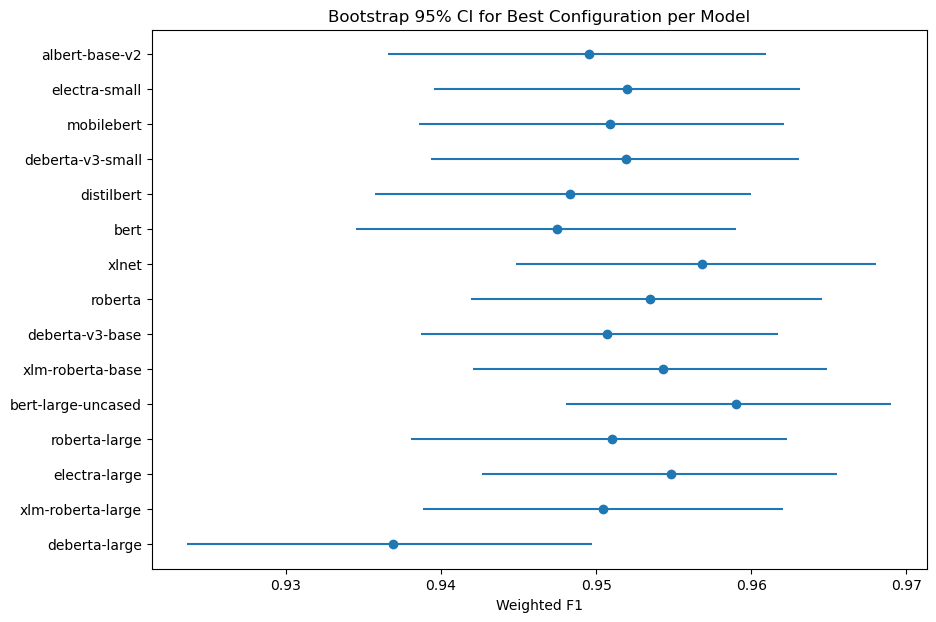

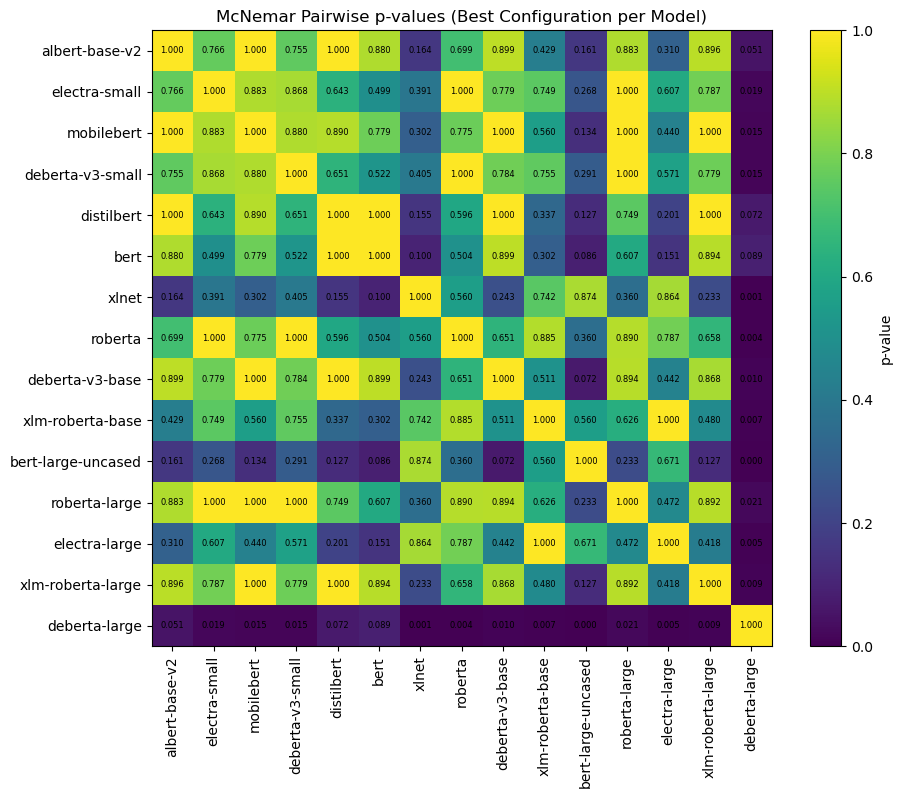

Done. Plots and summary CSVs have been generated.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# FILE PATHS 
perf_path = "model_performance.csv"
bootstrap_path = "model_bootstrap_ci_results.csv"
mcnemar_path = "mcnemar_pairwise_results.csv"

# LOAD DATA 
perf = pd.read_csv(perf_path)
# Align with training CSV columns: f1, train_time_sec, pred_time_sec
perf = perf.rename(
    columns={
        k: v
        for k, v in {
            "f1": "weighted_f1",
            "train_time_sec": "training_time",
            "pred_time_sec": "prediction_time",
        }.items()
        if k in perf.columns
    }
)
boot = pd.read_csv(bootstrap_path)
mcnemar = pd.read_csv(mcnemar_path)

# STANDARDIZE MODEL NAMES / GROUPS
group_map = {
    "albert-base-v2": "Small",
    "electra-small": "Small",
    "mobilebert": "Small",
    "deberta-v3-small": "Small",
    "distilbert": "Small",
    "bert": "Medium",
    "xlnet": "Medium",
    "roberta": "Medium",
    "deberta-v3-base": "Medium",
    "xlm-roberta-base": "Medium",
    "bert-large-uncased": "Large",
    "roberta-large": "Large",
    "electra-large": "Large",
    "xlm-roberta-large": "Large",
    "deberta-large": "Large",
}

perf["group"] = perf["model"].map(group_map)

# force integer max_length if needed
perf["max_length"] = perf["max_length"].astype(int)

# ORDERING
model_order = [
    "albert-base-v2",
    "electra-small",
    "mobilebert",
    "deberta-v3-small",
    "distilbert",
    "bert",
    "xlnet",
    "roberta",
    "deberta-v3-base",
    "xlm-roberta-base",
    "bert-large-uncased",
    "roberta-large",
    "electra-large",
    "xlm-roberta-large",
    "deberta-large",
]

length_order = [128, 256, 512]

# HELPERS
def save_or_show(fig, filename=None, dpi=300):
    if filename:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight")
    plt.show()

def make_heatmap(df, value_col, title, cbar_label, filename=None, fmt=".4f"):
    pivot = (
        df.pivot(index="model", columns="max_length", values=value_col)
          .reindex(index=model_order, columns=length_order)
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Max Input Length")
    ax.set_ylabel("Model")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=7)

    save_or_show(fig, filename)

# HEATMAPS
make_heatmap(
    perf,
    value_col="weighted_f1",
    title="Weighted F1 by Model and Input Length",
    cbar_label="Weighted F1",
    filename="weighted_f1_heatmap.png"
)

make_heatmap(
    perf,
    value_col="accuracy",
    title="Accuracy by Model and Input Length",
    cbar_label="Accuracy",
    filename="accuracy_heatmap.png"
)

make_heatmap(
    perf,
    value_col="training_time",
    title="Training Time by Model and Input Length",
    cbar_label="Training Time (s)",
    filename="training_time_heatmap.png",
    fmt=".1f"
)

make_heatmap(
    perf,
    value_col="prediction_time",
    title="Prediction Time by Model and Input Length",
    cbar_label="Prediction Time (s)",
    filename="prediction_time_heatmap.png",
    fmt=".2f"
)

# BEST CONFIGURATION PER MODEL
best_perf = (
    perf.sort_values(["model", "weighted_f1", "accuracy"], ascending=[True, False, False])
        .groupby("model", as_index=False)
        .first()
)

best_perf["group"] = best_perf["model"].map(group_map)
best_perf = best_perf.set_index("model").loc[model_order].reset_index()

# BAR CHART: BEST WEIGHTED F1 PER MODEL
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(best_perf["model"], best_perf["weighted_f1"])
ax.set_title("Best Weighted F1 per Model")
ax.set_xlabel("Model")
ax.set_ylabel("Weighted F1")
ax.tick_params(axis="x", rotation=60)

for i, v in enumerate(best_perf["weighted_f1"]):
    ax.text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=8)

save_or_show(fig, "best_weighted_f1_per_model.png")

# TRADEOFF PLOT: WEIGHTED F1 VS PREDICTION TIME
fig, ax = plt.subplots(figsize=(10, 6))

for grp in ["Small", "Medium", "Large"]:
    subset = best_perf[best_perf["group"] == grp]
    ax.scatter(subset["prediction_time"], subset["weighted_f1"], s=100, label=grp)
    for _, row in subset.iterrows():
        ax.annotate(
            f"{row['model']} ({int(row['max_length'])})",
            (row["prediction_time"], row["weighted_f1"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

ax.set_title("Performance vs Prediction Time")
ax.set_xlabel("Prediction Time (s)")
ax.set_ylabel("Weighted F1")
ax.legend(title="Group")

save_or_show(fig, "performance_vs_prediction_time.png")

# AVG BY GROUP AND LENGTH
group_avg = (
    perf.groupby(["group", "max_length"], as_index=False)
        .agg({
            "accuracy": "mean",
            "weighted_f1": "mean",
            "training_time": "mean",
            "prediction_time": "mean"
        })
)

fig, ax = plt.subplots(figsize=(8, 5))
for grp in ["Small", "Medium", "Large"]:
    subset = group_avg[group_avg["group"] == grp].sort_values("max_length")
    ax.plot(subset["max_length"], subset["weighted_f1"], marker="o", label=grp)

ax.set_title("Average Weighted F1 by Group and Input Length")
ax.set_xlabel("Max Input Length")
ax.set_ylabel("Mean Weighted F1")
ax.set_xticks(length_order)
ax.legend(title="Group")

save_or_show(fig, "avg_weighted_f1_by_group_and_length.png")

# BOOTSTRAP CI PLOT
# Expected columns in bootstrap CSV:
# model, best_len, accuracy_mean, accuracy_ci_lower, accuracy_ci_upper,
# weighted_f1_mean, weighted_f1_ci_lower, weighted_f1_ci_upper

boot_cols = {c.lower(): c for c in boot.columns}
print("Bootstrap columns:", list(boot.columns))

# Try common variants automatically
rename_map = {}
for c in boot.columns:
    lc = c.lower()
    if lc in ["best_len", "best_length", "max_length"]:
        rename_map[c] = "best_len"
    elif lc in ["weighted_f1_mean", "f1_mean", "mean_weighted_f1", "weighted_f1", "f1_weighted"]:
        rename_map[c] = "weighted_f1_mean"
    elif lc in ["weighted_f1_ci_lower", "f1_ci_lower", "f1_ci_low", "weighted_f1_lower", "ci_lower_f1"]:
        rename_map[c] = "weighted_f1_ci_lower"
    elif lc in ["weighted_f1_ci_upper", "f1_ci_upper", "f1_ci_high", "weighted_f1_upper", "ci_upper_f1"]:
        rename_map[c] = "weighted_f1_ci_upper"
    elif lc == "model":
        rename_map[c] = "model"

boot = boot.rename(columns=rename_map)

required_boot = {"model", "weighted_f1_mean", "weighted_f1_ci_lower", "weighted_f1_ci_upper"}
missing_boot = required_boot - set(boot.columns)

if not missing_boot:
    boot_plot = boot.copy()
    boot_plot["group"] = boot_plot["model"].map(group_map)
    boot_plot = boot_plot.set_index("model").loc[[m for m in model_order if m in boot_plot["model"].values]].reset_index()

    y = np.arange(len(boot_plot))
    x = boot_plot["weighted_f1_mean"].values
    xerr = np.vstack([
        x - boot_plot["weighted_f1_ci_lower"].values,
        boot_plot["weighted_f1_ci_upper"].values - x
    ])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.errorbar(x, y, xerr=xerr, fmt='o')
    ax.set_yticks(y)
    ax.set_yticklabels(boot_plot["model"])
    ax.set_xlabel("Weighted F1")
    ax.set_title("Bootstrap 95% CI for Best Configuration per Model")
    ax.invert_yaxis()

    save_or_show(fig, "bootstrap_ci_weighted_f1.png")
else:
    print("Skipping bootstrap CI plot. Missing columns:", missing_boot)

# MCNEMAR HEATMAP
# Expected columns commonly:
# model_a, len_a, model_b, len_b, chi2, p_value, b, c

rename_map = {}
for c in mcnemar.columns:
    lc = c.lower()
    if lc in ["model_a", "model1", "a_model"]:
        rename_map[c] = "model_a"
    elif lc in ["model_b", "model2", "b_model"]:
        rename_map[c] = "model_b"
    elif lc in ["p_value", "pvalue", "p"]:
        rename_map[c] = "p_value"

mcnemar = mcnemar.rename(columns=rename_map)

required_mcnemar = {"model_a", "model_b", "p_value"}
missing_mcnemar = required_mcnemar - set(mcnemar.columns)

if not missing_mcnemar:
    models_present = sorted(set(mcnemar["model_a"]).union(set(mcnemar["model_b"])))
    ordered_present = [m for m in model_order if m in models_present]

    pmat = pd.DataFrame(np.nan, index=ordered_present, columns=ordered_present)

    for _, row in mcnemar.iterrows():
        a = row["model_a"]
        b = row["model_b"]
        p = row["p_value"]
        if a in pmat.index and b in pmat.columns:
            pmat.loc[a, b] = p
            pmat.loc[b, a] = p

    np.fill_diagonal(pmat.values, 1.0)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(pmat.values, aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(len(pmat.columns)))
    ax.set_xticklabels(pmat.columns, rotation=90)
    ax.set_yticks(range(len(pmat.index)))
    ax.set_yticklabels(pmat.index)
    ax.set_title("McNemar Pairwise p-values (Best Configuration per Model)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("p-value")

    for i in range(pmat.shape[0]):
        for j in range(pmat.shape[1]):
            val = pmat.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=6)

    save_or_show(fig, "mcnemar_pvalue_heatmap.png")
else:
    print("Skipping McNemar heatmap. Missing columns:", missing_mcnemar)

# EXPORT SUMMARY TABLES
best_perf.to_csv("best_configuration_per_model.csv", index=False)
group_avg.to_csv("group_average_by_length.csv", index=False)

print("Done. Plots and summary CSVs have been generated.")